In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score


In [5]:
# Loading  MNIST dataset
mnist = fetch_openml('mnist_784', version=1)
X, y = mnist.data, mnist.target.astype(int)
print("MNIST raw shape:", X.shape, y.shape)


C:\Users\Dell\anaconda3\lib\site-packages\sklearn\datasets\_openml.py:932: FutureWarning: The default value of `parser` will change from `'liac-arff'` to `'auto'` in 1.4. You can set `parser='auto'` to silence this warning. Therefore, an `ImportError` will be raised from 1.4 if the dataset is dense and pandas is not installed. Note that the pandas parser may return different data types. See the Notes Section in fetch_openml's API doc for details.
  warn(


MNIST raw shape: (70000, 784) (70000,)


In [6]:
# Data Preprocessing for MNIST -> Fisher9
# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Reduce to 9D (Fisher9 approximation using PCA)
pca = PCA(n_components=9)
X_fisher9 = pca.fit_transform(X_scaled)

X_train, X_test, y_train, y_test = train_test_split(
    X_fisher9, y, stratify=y, test_size=0.3, random_state=42
)

print("MNIST Fisher9 shape:", X_train.shape, X_test.shape)


MNIST Fisher9 shape: (49000, 9) (21000, 9)


In [7]:
# Loading  Mushroom dataset 
mushroom = pd.read_csv("mushrooms.csv")

# Separate features and labels
X_m = mushroom.drop("class", axis=1)
y_m = mushroom["class"]

print("Mushroom raw shape:", X_m.shape, y_m.shape)


Mushroom raw shape: (8124, 22) (8124,)


In [8]:
# Mushroom data Preprocessing.
# Encode categorical features
X_m_encoded = pd.get_dummies(X_m)
y_m_encoded = LabelEncoder().fit_transform(y_m)

# Train/Test split (70/30 stratified)
X_train_m, X_test_m, y_train_m, y_test_m = train_test_split(
    X_m_encoded, y_m_encoded, stratify=y_m_encoded, test_size=0.3, random_state=42
)

print("Mushroom dataset shape:", X_train_m.shape, X_test_m.shape)


Mushroom dataset shape: (5686, 117) (2438, 117)


# PROBLEM 1: kNN and Parzen Window classifiers hyper parameter sweeps

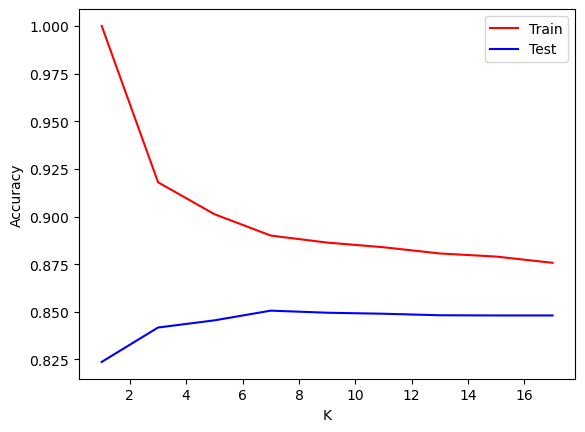

In [9]:
#KNN Sweep
# Subsample MNIST to 10% for efficiency
subsample = int(0.1 * len(X_train))
X_train_sub, y_train_sub = X_train[:subsample], y_train[:subsample]

def knn_sweep(trainX, trainY, testX, testY, K=[1,3,5,7,9,11,13,15,17]):
    train_acc, test_acc = [], []
    for k in K:
        clf = KNeighborsClassifier(n_neighbors=k)
        clf.fit(trainX, trainY)
        train_acc.append(accuracy_score(trainY, clf.predict(trainX)))
        test_acc.append(accuracy_score(testY, clf.predict(testX)))
    plt.plot(K, train_acc, 'r-', label='Train')
    plt.plot(K, test_acc, 'b-', label='Test')
    plt.xlabel("K")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.show()

knn_sweep(X_train_sub, y_train_sub, X_test, y_test)


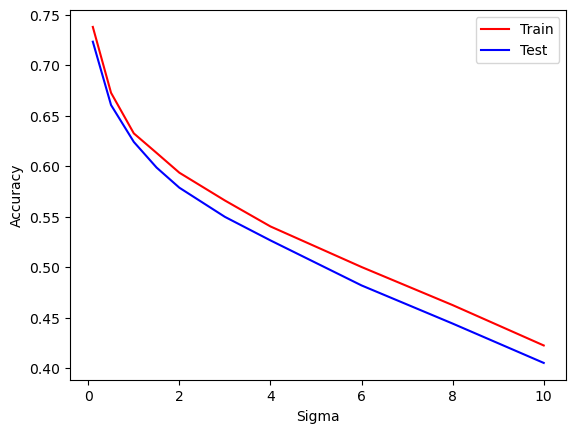

In [10]:
# Parzen Sweep
def parzen_sweep(trainX, trainY, testX, testY, sigma=[0.1,0.5,1,1.5,2,3,4,6,8,10]):
    train_acc, test_acc = [], []
    for s in sigma:
        clf = GaussianNB(var_smoothing=s)
        clf.fit(trainX, trainY)
        train_acc.append(accuracy_score(trainY, clf.predict(trainX)))
        test_acc.append(accuracy_score(testY, clf.predict(testX)))
    plt.plot(sigma, train_acc, 'r-', label='Train')
    plt.plot(sigma, test_acc, 'b-', label='Test')
    plt.xlabel("Sigma")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.show()

parzen_sweep(X_train_sub, y_train_sub, X_test, y_test)


# PROBLEM 2: Pair-wise LogisDc Regression Model

In [11]:
pairs = []
for i in range(10):
    for j in range(i+1, 10):
        mask = (y_train==i) | (y_train==j)
        X_train_pair, y_train_pair = X_train[mask], y_train[mask]
        mask = (y_test==i) | (y_test==j)
        X_test_pair, y_test_pair = X_test[mask], y_test[mask]

        clf = LogisticRegression(max_iter=200)
        clf.fit(X_train_pair, y_train_pair)
        train_acc = accuracy_score(y_train_pair, clf.predict(X_train_pair))
        test_acc = accuracy_score(y_test_pair, clf.predict(X_test_pair))
        pairs.append([i, j, train_acc, test_acc])

df_pairs = pd.DataFrame(pairs, columns=["Class1","Class2","TrainAcc","TestAcc"])
df_pairs_sorted = df_pairs.sort_values(by="TestAcc")
print(df_pairs_sorted)


    Class1  Class2  TrainAcc   TestAcc
34       4       9  0.772077  0.766812
43       7       9  0.890638  0.889591
37       5       8  0.900826  0.897514
25       3       5  0.911021  0.906591
28       3       8  0.916428  0.915513
4        0       5  0.936872  0.930895
44       8       9  0.939884  0.937364
20       2       6  0.939007  0.939904
22       2       8  0.944571  0.942099
17       2       3  0.943389  0.943855
32       4       7  0.953451  0.946871
38       5       9  0.957804  0.953780
35       5       6  0.959055  0.961587
19       2       5  0.963166  0.962666
30       4       5  0.960961  0.962700
29       3       9  0.966261  0.964294
33       4       8  0.965564  0.964591
15       1       8  0.960257  0.965087
18       2       4  0.968252  0.965975
7        0       8  0.972734  0.967953
2        0       3  0.971722  0.968194
42       7       8  0.970047  0.968839
1        0       2  0.969152  0.969290
27       3       7  0.972090  0.971363
5        0       6  0.975

# PROBLEM 3: Support Vector Machine Classifier

In [12]:
def svm_explore(trainX, trainY, testX, testY, c1, c2, C=[5,10,15,20,50,100], d=[1,2,3,4,5]):
    mask = (trainY==c1) | (trainY==c2)
    X_train_pair, y_train_pair = trainX[mask], trainY[mask]
    mask = (testY==c1) | (testY==c2)
    X_test_pair, y_test_pair = testX[mask], testY[mask]

    results = []
    for c in C:
        for deg in d:
            clf = SVC(kernel='poly', C=c, degree=deg)
            clf.fit(X_train_pair, y_train_pair)
            train_acc = accuracy_score(y_train_pair, clf.predict(X_train_pair))
            test_acc = accuracy_score(y_test_pair, clf.predict(X_test_pair))
            results.append([c1, c2, c, deg, train_acc, test_acc, len(clf.support_)])
    return pd.DataFrame(results, columns=["Class1","Class2","C","Degree","TrainAcc","TestAcc","SupportVectors"])

df_svm = svm_explore(X_train, y_train, X_test, y_test, 3, 5)
print(df_svm)


    Class1  Class2    C  Degree  TrainAcc   TestAcc  SupportVectors
0        3       5    5       1  0.913039  0.906343            2220
1        3       5    5       2  0.946910  0.942517            1540
2        3       5    5       3  0.963687  0.960852            1324
3        3       5    5       4  0.968252  0.955154            1661
4        3       5    5       5  0.975154  0.958127            1804
5        3       5   10       1  0.913039  0.906343            2209
6        3       5   10       2  0.947653  0.942765            1496
7        3       5   10       3  0.964430  0.960109            1203
8        3       5   10       4  0.971013  0.954658            1459
9        3       5   10       5  0.978127  0.957879            1553
10       3       5   15       1  0.912933  0.906343            2206
11       3       5   15       2  0.948078  0.943013            1483
12       3       5   15       3  0.964536  0.959861            1152
13       3       5   15       4  0.972181  0.955

# PROBLEM 4: Parameter Sweep on Decision Trees

In [13]:
def tree_sweep(trainX, trainY, testX, testY,
               size=[10,20,30,40,50,60,70,80,90,100],
               purity=[60,65,70,75,80,85,90,95]):
    results = []
    for s in size:
        for p in purity:
            clf = DecisionTreeClassifier(max_leaf_nodes=s, min_samples_split=int(len(trainX)*p/100))
            clf.fit(trainX, trainY)
            train_acc = accuracy_score(trainY, clf.predict(trainX))
            test_acc = accuracy_score(testY, clf.predict(testX))
            results.append([s, p, train_acc, test_acc])
    return pd.DataFrame(results, columns=["Size","Purity","TrainAcc","TestAcc"])

df_tree = tree_sweep(X_train_m, y_train_m, X_test_m, y_test_m)
print(df_tree)


    Size  Purity  TrainAcc   TestAcc
0     10      60  0.888146  0.883511
1     10      65  0.888146  0.883511
2     10      70  0.888146  0.883511
3     10      75  0.888146  0.883511
4     10      80  0.888146  0.883511
..   ...     ...       ...       ...
75   100      75  0.888146  0.883511
76   100      80  0.888146  0.883511
77   100      85  0.888146  0.883511
78   100      90  0.888146  0.883511
79   100      95  0.888146  0.883511

[80 rows x 4 columns]


# Visualization: plot accuracy vs C for each polynomial degree

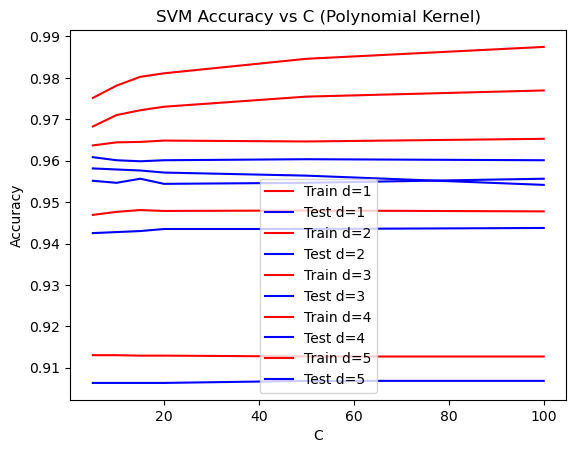

In [14]:
for deg in df_svm["Degree"].unique():
    subset = df_svm[df_svm["Degree"]==deg]
    plt.plot(subset["C"], subset["TrainAcc"], 'r-', label=f'Train d={deg}')
    plt.plot(subset["C"], subset["TestAcc"], 'b-', label=f'Test d={deg}')
plt.xlabel("C")
plt.ylabel("Accuracy")
plt.title("SVM Accuracy vs C (Polynomial Kernel)")
plt.legend()
plt.show()


# Visualization 1: For fixed size, plot purity vs accuracy

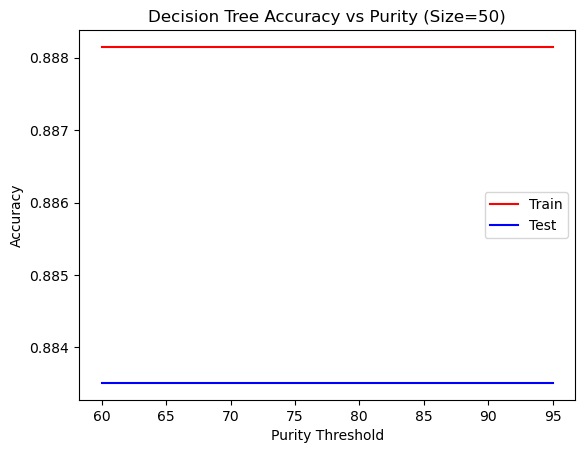

In [15]:
fixed_size = 50  
subset = df_tree[df_tree["Size"]==fixed_size]
plt.plot(subset["Purity"], subset["TrainAcc"], 'r-', label='Train')
plt.plot(subset["Purity"], subset["TestAcc"], 'b-', label='Test')
plt.xlabel("Purity Threshold")
plt.ylabel("Accuracy")
plt.title(f"Decision Tree Accuracy vs Purity (Size={fixed_size})")
plt.legend()
plt.show()


# Visualization 2: For fixed purity, plot size vs accuracy

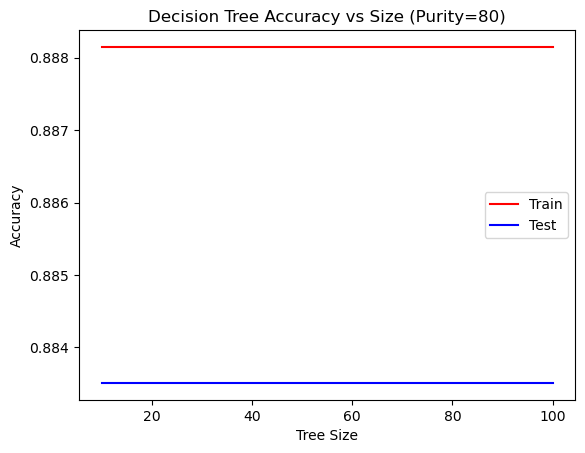

In [16]:
fixed_purity = 80  
subset = df_tree[df_tree["Purity"]==fixed_purity]
plt.plot(subset["Size"], subset["TrainAcc"], 'r-', label='Train')
plt.plot(subset["Size"], subset["TestAcc"], 'b-', label='Test')
plt.xlabel("Tree Size")
plt.ylabel("Accuracy")
plt.title(f"Decision Tree Accuracy vs Size (Purity={fixed_purity})")
plt.legend()
plt.show()
